In [2]:


%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("weight-height.csv")

In [4]:
df.head()


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [6]:
df.Gender.replace({'Male':1, 'Female':0}, inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_13952\2139048594.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Gender.replace({'Male':1, 'Female':0}, inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_13952\2139048594.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Gender.replace({'Male

In [7]:
df.corr()

,Gender,Height,Weight
Gender,1.000000,0.691072,0.796723
Height,0.691072,1.000000,0.924756
Weight,0.796723,0.924756,1.000000


<Axes: title={'center': 'Weight and Height in adults'}, xlabel='Height', ylabel='Weight'>

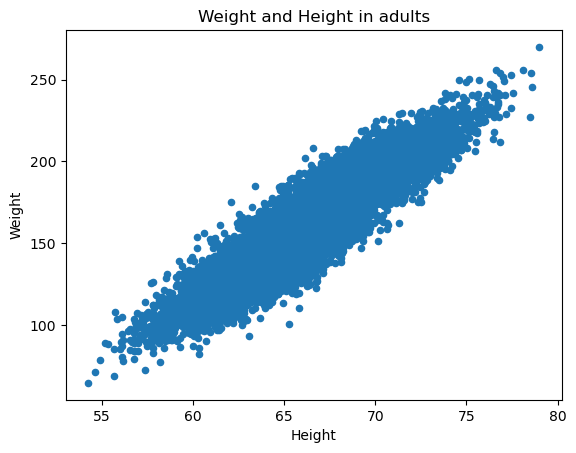

In [8]:
df.plot(kind='scatter', x='Height', y='Weight',
       title='Weight and Height in adults')

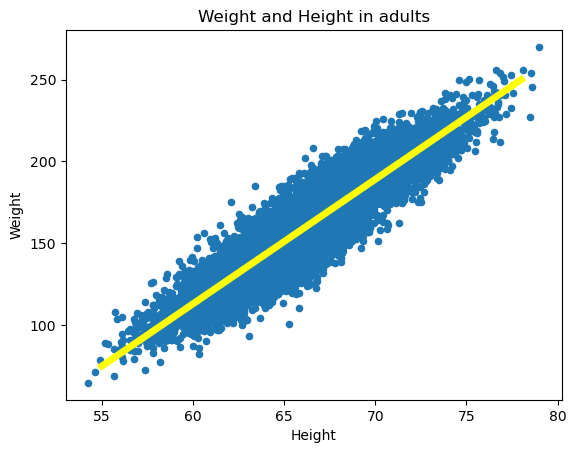

In [11]:
df.plot(kind='scatter', x='Height', y='Weight',
       title='Weight and Height in adults')
plt.plot([55,78], [75,250], color='yellow', linewidth=5)

# Our MOdel

In [37]:
def line(x, m=0, c=0):
    y=m*x+c  #y=mx+c
    return  y


# Cost Function

In [38]:
def mean_squared_error(y_true, y_pred):
    s=(y_true-y_pred)**2
    return s.mean()


In [39]:
X=df[['Height']].values
y_true=df[['Weight']].values

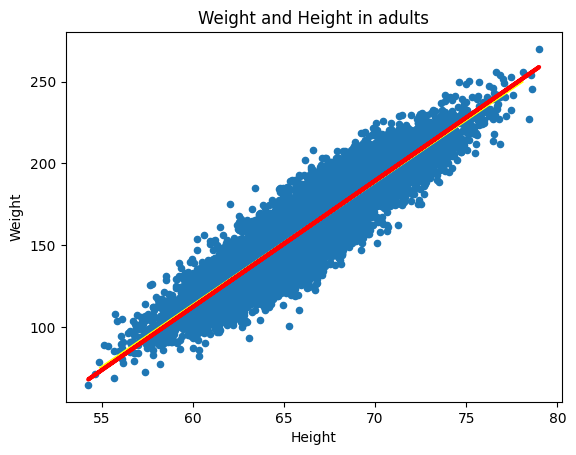

In [47]:
y_pred=line(X, 7.71728764,-350.73719181)  #y=mx+c


df.plot(kind='scatter', x='Height', y='Weight',
       title='Weight and Height in adults')

plt.plot([55,78], [75,250], color='yellow', linewidth=3)

plt.plot(X,y_pred, color='red', linewidth=3)

In [48]:
mean_squared_error(y_true,y_pred)**(0.5)

np.float64(12.218571272826035)

In [42]:
# Weight = 7.7(Height) + ( -351.4)
#

<>:1: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
<>:1: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
/tmp/ipykernel_1979/3798586646.py:1: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
  Weight = 7.7(Height) + ( -351.4)


NameError: name 'Height' is not defined

In [46]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y_true)

LinearRegression()

In [44]:
lr.coef_

array([[7.71728764]])

In [45]:
lr.intercept_

array([-350.73719181])

In [58]:
pd.DataFrame({'originalWeigth':y_true.reshape(10000), "predictedweigth":y_pred.reshape(10000)})

,originalWeigth,predictedweigth
0,241.893563,219.161480
1,162.310473,180.072546
2,212.740856,221.191809
3,220.042470,202.831401
4,206.349801,188.560728
...,...,...
9995,136.777454,159.936199
9996,170.867906,166.839332
9997,128.475319,142.150475
9998,163.852461,182.019919


In [59]:
from sklearn.metrics import mean_squared_error, r2_score
r2_score(y_true,y_pred)

0.8551742120609958